mc time :0.005180835723876953 

horizon: 0, foresee_time:0.0007007122039794922 

genUT foresee_time:0.00030922889709472656 

mc time :0.010242938995361328 

horizon: 1, foresee_time:0.00061798095703125 

genUT foresee_time:0.0005745887756347656 

mc time :0.015447139739990234 

horizon: 2, foresee_time:0.00091552734375 

genUT foresee_time:0.0008492469787597656 

mc time :0.020650863647460938 

horizon: 3, foresee_time:0.0011227130889892578 

genUT foresee_time:0.0010979175567626953 

mc time :0.026423931121826172 

horizon: 4, foresee_time:0.0017445087432861328 

genUT foresee_time:0.0013680458068847656 

mc time :0.03235816955566406 

horizon: 5, foresee_time:0.001744985580444336 

genUT foresee_time:0.001695394515991211 

mc time :0.03597259521484375 

horizon: 6, foresee_time:0.0026557445526123047 

genUT foresee_time:0.002081155776977539 

mc time :0.04102015495300293 

horizon: 7, foresee_time:0.002191781997680664 

genUT foresee_time:0.0022165775299072266 

mc time :0.0466067790

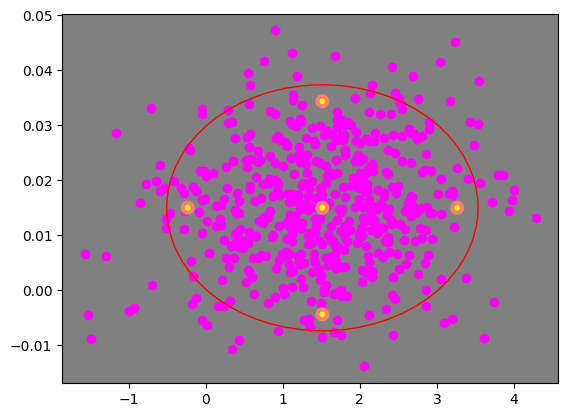

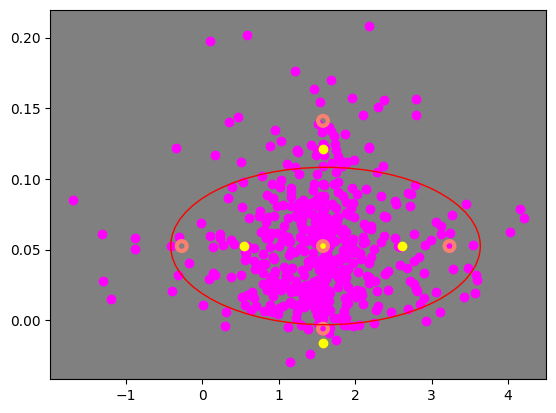

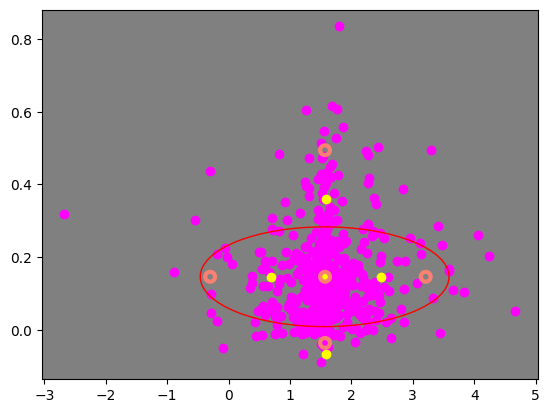

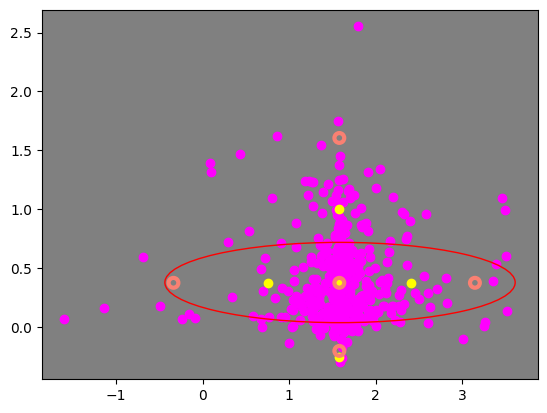

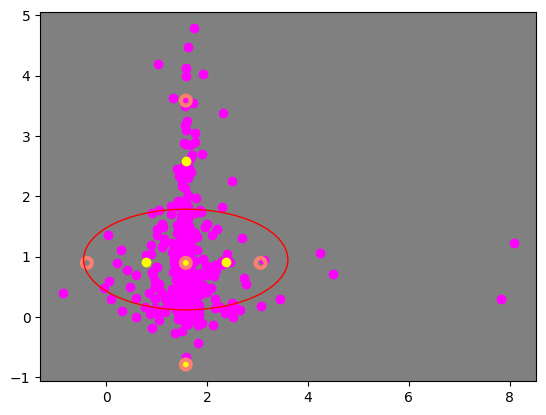

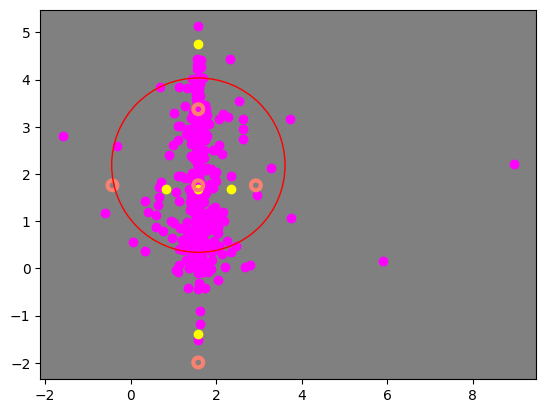

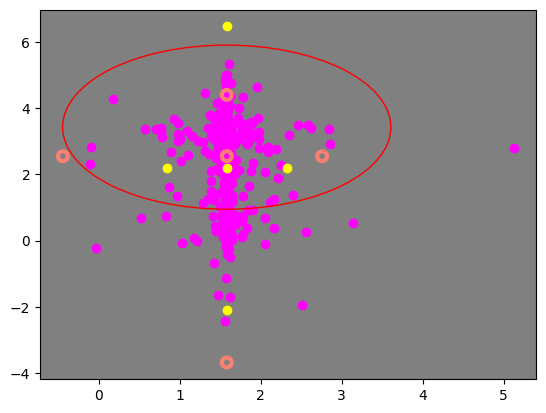

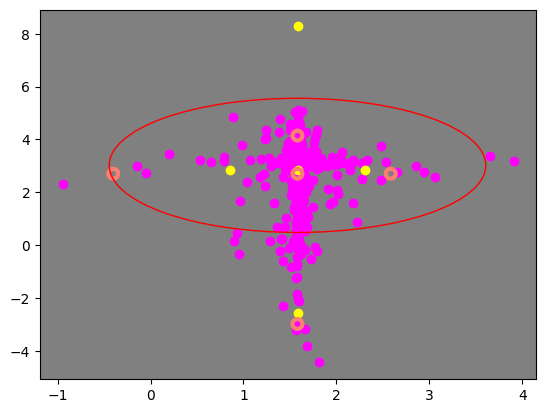

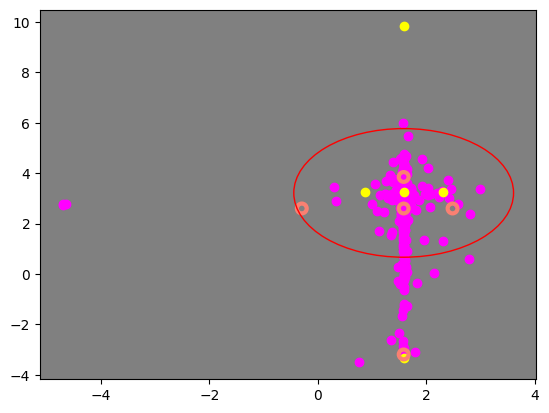

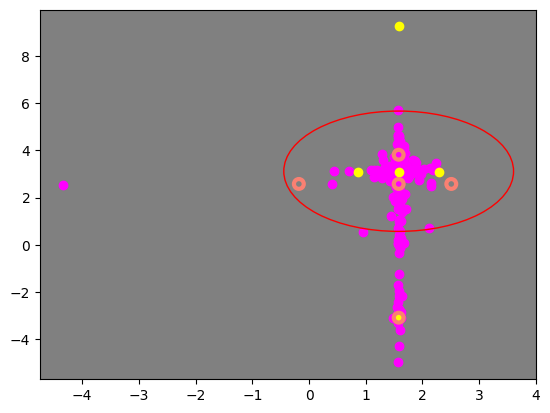

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import numpy as np
import time
import math
#from jax import jit

# plot ellipse

def confidence_ellipse(mu, cov, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of `x` and `y`

    Parameters
    ----------
    x, y : array_like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    Returns
    -------
    matplotlib.patches.Ellipse

    Other parameters
    ----------------
    kwargs : `~matplotlib.patches.Patch` properties
    """

    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensionl dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor=facecolor,
        **kwargs)

    # Calculating the stdandard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = mu[0,0]

    # calculating the stdandard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = mu[1,0]

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def dynamics_step( base_term, state_dot, dt ):
    next_state = base_term + state_dot * dt
#     print(f"next_state:{next_state}")
    return next_state

def dynamics_xdot(state, action = np.array([0])):
    return 20 * np.array([np.cos(state[0,0])+0.01, np.sin(state[1,0])+0.01]).reshape(-1,1)

# assume this is true dynamics
def dynamics_xdot_noisy(state, action = np.array([0])):
    xdot = dynamics_xdot(state, action)
    error_square = 0.01 + np.square(xdot) # /2  #never let it be 0!!!!
    cov = np.diag( error_square[:,0] )
    xdot = xdot + xdot/2 #X_dot = X_dot + X_dot/6
    return xdot, cov

# @jit
def get_mean( sigma_points, weights ):
    weighted_points = sigma_points * weights[0]
    mu = np.sum( weighted_points, 1 ).reshape(-1,1)
    return mu

# @jit
def get_mean_cov(sigma_points, weights):
    
    # mean
    weighted_points = sigma_points * weights[0]
    mu = np.sum( weighted_points, 1 ).reshape(-1,1)
    
    # covariance
    centered_points = sigma_points - mu
    weighted_centered_points = centered_points * weights[0] 
    cov = weighted_centered_points @ centered_points.T
    return mu, cov

# moments for data generation
# assume rows independent. therefore disginal eleemnts are 0. skewness and kurtosis only for 1-D data
def get_mean_cov_skew_kurt_for_generation( sigma_points, weights ):
    # mean
#     weighted_points = sigma_points * weights[0]
#     mu = np.sum( weighted_points, 1 ).reshape(-1,1)    
#     centered_points = sigma_points - mu    
#     # covariance
# #     weighted_centered_points = centered_points * weights[0] 
# #     cov = weighted_centered_points @ centered_points.T   
#     cov = np.diag(np.sum(centered_points**2 * weights[0], axis=1))
#     # print(f"COV: {cov}")
#     # Skewness times cov_root^-3
#     skewness = np.sum(centered_points**3 * weights[0], axis=1) #/ cov[0,0]**(3/2) # for scipy    
#     skewness[0] = skewness[0] / max(cov[0,0],0.01)**(3/2)
#     skewness[1] = skewness[1] / max(cov[1,1],0.01)**(3/2)
#     # kurtosis times cov_root^-4
#     kurt = np.sum(centered_points**4 * weights[0], axis=1)# / cov[0,0]**(4/2)  # -3 # -3 for scipy
#     kurt[0] = kurt[0]/max(cov[0,0],0.01)**(4/2)
#     kurt[1] = kurt[1]/max(cov[1,1],0.01)**(4/2)
#     return mu, cov, skewness.reshape(-1,1), kurt.reshape(-1,1)

    weighted_points = sigma_points * weights[0]
    mu = np.sum( weighted_points, 1 ).reshape(-1,1)    
    centered_points = sigma_points - mu    

    cov = np.diag(np.sum(centered_points**2 * weights[0], axis=1))
    skewness = np.sum(centered_points**3 * weights[0], axis=1) #/ cov[0,0]**(3/2) # for scipy   
    skewness = skewness / np.diag(cov)**(3/2) 

    kurt = np.sum(centered_points**4 * weights[0], axis=1)# / cov[0,0]**(4/2)  # -3 # -3 for scipy
    kurt = kurt / np.diag(cov)**(4/2)
    
    return mu, cov, skewness.reshape(-1,1), kurt.reshape(-1,1)

# actual moments
def get_mean_cov_skew_kurt( sigma_points, weights ):
    # mean
    weighted_points = sigma_points * weights[0]
    mu = np.sum( weighted_points, 1 ).reshape(-1,1)    
    centered_points = sigma_points - mu    
    # covariance
#     weighted_centered_points = centered_points * weights[0] 
#     cov = weighted_centered_points @ centered_points.T    
    cov = np.diag(np.sum(centered_points**2 * weights[0], axis=1))
    # Skewness times cov_root^-3
    skewness = np.sum(centered_points**3 * weights[0], axis=1) #/ cov[0,0]**(3/2) # for scipy    
    # kurtosis times cov_root^-4
    kurt = np.sum(centered_points**4 * weights[0], axis=1) #/ cov[0,0]**(4/2)-3 # for scipy
    return mu, cov, skewness.reshape(-1,1), kurt.reshape(-1,1)

#@jit
def get_ut_cov_root_diagonal(cov):
    offset = 0.000  # TODO: make sure not zero here
    root0 = np.sqrt((offset+cov[0,0]))
    root1 = np.sqrt((offset+cov[1,1]))
    # return cov
    root_term = np.diag( np.array([root0, root1]) )
    return root_term

def pilco_propagate(mean, cov):
    mu_new, cov_new = dynamics_xdot_noisy(mean)
    # print(f"data: {mean}, {mu_new}, {cov_new}")
    return dynamics_step( mean, mu_new, dt ), cov + cov_new * dt**2

def mc_propagate(points):
    new_points = np.copy(points)
    for i in range(points.shape[1]):
        mu, cov = dynamics_xdot_noisy(points[:,i].reshape(-1,1))
        sample = np.array([  np.random.normal(mu[0,0], np.sqrt(cov[0,0])), np.random.normal(mu[1,0], np.sqrt(cov[1,1]))  ]).reshape(-1,1) 
        points[:,i] = dynamics_step(points[:,i].reshape(-1,1), sample, dt)[:,0]
    return points

#@jit
def initialize_sigma_points(X):
    # return 2N + 1 points
    n = X.shape[0]
    num_points = 2*n + 1
    sigma_points = np.repeat( X, num_points, axis=1 )
    weights = np.ones((1,num_points)) * 1.0/( num_points )
    return sigma_points, weights

def generate_sigma_points_gaussian( mu, cov_root, base_term, factor ):
    n = mu.shape[0]     
    N = 2*n + 1 # total points

    # k = 1.0#0.5 # n-3 # 0.5**
    
    alpha = 1.0
    beta = 0.0#2.0#2.0 # optimal for gaussian
    k = 1.0
    Lambda = alpha**2 * ( n+k ) - n
    new_points = dynamics_step(base_term, mu, factor) # new_points = base_term + factor * mu
    new_weights = np.array([[1.0*Lambda/(n+Lambda)]])    
    new_weights_cov = np.array([[ 1.0*Lambda/(n+Lambda) + 1 - alpha**2 + beta]])
    for i in range(n):
#         print(f"new_points:{new_points}")
        new_points = np.append( new_points, dynamics_step(base_term, (mu - np.sqrt(n+Lambda) * cov_root[:,i].reshape(-1,1)), factor) , axis = 1 )
        new_points = np.append( new_points, dynamics_step(base_term, (mu + np.sqrt(n+Lambda) * cov_root[:,i].reshape(-1,1)), factor) , axis = 1 )
        new_weights = np.append( new_weights, np.array([[1.0/(n+Lambda)/2.0]]), axis = 1 )
        new_weights = np.append( new_weights, np.array([[1.0/(n+Lambda)/2.0]]), axis = 1 )
        new_weights_cov = np.append( new_weights_cov, np.array([[1.0/(n+Lambda)/2.0]]), axis = 1 )
        new_weights_cov = np.append( new_weights_cov, np.array([[1.0/(n+Lambda)/2.0]]), axis = 1 )
    # print(f"weights1: {new_weights}")
    # print(f"weights2: {new_weights_cov}")
    return new_points, new_weights

# @jit
def generate_sigma_points_gaussian_GenUT( mu, cov_root, skewness, kurt, base_term, factor ):
    n = mu.shape[0]     
    N = 2*n + 1 # total points
    
#     u = 0.5#k
    # print(f"GENERATE mu: {mu}, cov_root:{cov_root}, skew:{skewness}, kurt:{kurt}")
#     cov_3 = np.diag(np.reciprocal(np.diagonal(cov_root**3)))
#     cov_4 = np.diag(np.reciprocal(np.diagonal(cov_root**4)))
    u = 0.5 * ( - skewness + np.sqrt( 4 * kurt - 3 * ( skewness )**2 ) )
    v = u + skewness
#     v = u + cov_3 @ skewness
#     print(f"cov_root:{cov_root}, \n 3: {cov_3}, \n 4: {cov_4}")
    # print(f"u:{u.T},\n v:{v.T},\n term:{4 * kurt - 3 * ( skewness )**2} ")
    
    w2 = (1.0 / v) / (u+v)
    w1 = (w2 * v) / u
    
    w0 = np.array([1 - np.sum(w1) - np.sum(w2)])
    
    U = np.diag(u[:,0])
    V = np.diag(v[:,0])
    points0 = mu    
    points1 = mu - cov_root @ U
    points2 = mu + cov_root @ V
    new_points = np.concatenate( (points0, points1, points2), axis=1 )
    new_weights = np.concatenate( (w0.reshape(-1,1), w1.reshape(1,-1), w2.reshape(1,-1)), axis=1 )
    
    return new_points, new_weights
    w0 = 1 - np.sum(w1) - np.sum(w2)
    # print(f"w0:{w0},\n w1:{w1},\n w2:{w2}")
    
#     k = 0.5 # n-3 # 0.5**
    new_points = dynamics_step(base_term, mu, factor) # new_points = base_term + factor * mu
    new_weights = np.array([[w0]])
    for i in range(n):
        new_points = np.append( new_points, dynamics_step(base_term, (mu - u[i,0]*cov_root[:,i].reshape(-1,1)), factor) , axis = 1 )
        new_points = np.append( new_points, dynamics_step(base_term, (mu + v[i,0]*cov_root[:,i].reshape(-1,1)), factor) , axis = 1 )
        new_weights = np.append( new_weights, np.array([[w1[i,0]]]), axis = 1 )
        new_weights = np.append( new_weights, np.array([[w2[i,0]]]), axis = 1 )
    return new_points, new_weights

# @jit
def sigma_point_expand(sigma_points, weights, control):
   
    n, N = sigma_points.shape   
    # dt_outer = 0  
    #TODO  
    mu, cov = dynamics_xdot_noisy(sigma_points[:,0].reshape(-1,1), control.reshape(-1,1))
    root_term = get_ut_cov_root_diagonal(cov) 
    temp_points, temp_weights = generate_sigma_points_gaussian( mu, root_term, sigma_points[:,0].reshape(-1,1), dt )
    new_points = np.copy( temp_points )
    new_weights = ( np.copy( temp_weights ) * weights[0,0]).reshape(1,-1)
        
    for i in range(1,N):
        mu, cov = dynamics_xdot_noisy(sigma_points[:,i].reshape(-1,1), control.reshape(-1,1))
        root_term = get_ut_cov_root_diagonal(cov)           
        temp_points, temp_weights = generate_sigma_points_gaussian( mu, root_term, sigma_points[:,i].reshape(-1,1), dt )
        new_points = np.append(new_points, temp_points, axis=1 )
        new_weights = np.append( new_weights, (temp_weights * weights[0,i]).reshape(1,-1) , axis=1 )

    return new_points, new_weights

def sigma_point_expand_GenUT(sigma_points, weights, control):
   
    n, N = sigma_points.shape   
    # dt_outer = 0  
    #TODO  
    mu, cov = dynamics_xdot_noisy(sigma_points[:,0].reshape(-1,1), control.reshape(-1,1))
    root_term = get_ut_cov_root_diagonal(cov) 
    temp_points, temp_weights = generate_sigma_points_gaussian_GenUT( mu, root_term, sigma_points[:,0].reshape(-1,1), dt )
    new_points = np.copy( temp_points )
    new_weights = ( np.copy( temp_weights ) * weights[0,0]).reshape(1,-1)
        
    for i in range(1,N):
        mu, cov = dynamics_xdot_noisy(sigma_points[:,i].reshape(-1,1), control.reshape(-1,1))
        root_term = get_ut_cov_root_diagonal(cov)           
        temp_points, temp_weights = generate_sigma_points_gaussian_GenUT( mu, root_term, sigma_points[:,i].reshape(-1,1), dt )
        new_points = np.append(new_points, temp_points, axis=1 )
        new_weights = np.append( new_weights, (temp_weights * weights[0,i]).reshape(1,-1) , axis=1 )

    return new_points, new_weights

#@jit
def sigma_point_compress( sigma_points, weights ):
    mu, cov = get_mean_cov( sigma_points, weights )
    cov_root_term = get_ut_cov_root_diagonal( cov )  
    base_term = np.zeros((mu.shape))
    return generate_sigma_points_gaussian( mu, cov_root_term, base_term, np.array([1.0]) )

#@jit
def sigma_point_compress_GenUT( sigma_points, weights ):
    mu, cov, skewness, kurt = get_mean_cov_skew_kurt_for_generation( sigma_points, weights )
    # print(f"mu:{mu}, cov:{cov}, skewness:{skewness}, kurtosis:{kurt}")
    cov_root_term = get_ut_cov_root_diagonal( cov )  
    base_term = np.zeros((mu.shape))
    return generate_sigma_points_gaussian_GenUT( mu, cov_root_term, skewness, kurt, base_term, np.array([1.0]) )

# @jit
def foresee_propagate( sigma_points, weights, action = np.array([0]), expanded_only=False ):
    
    #Expansion Layer
    expanded_sigma_points, expanded_weights = sigma_point_expand( sigma_points, weights, action )
    if expanded_only == False:
    # Compression layer
#     compressed_sigma_points, compressed_weights = sigma_point_compress_GenUT(expanded_sigma_points, expanded_weights)
        compressed_sigma_points, compressed_weights = sigma_point_compress(expanded_sigma_points, expanded_weights)
        return compressed_sigma_points, compressed_weights, expanded_sigma_points, expanded_weights
    else:
        return expanded_sigma_points, expanded_weights, expanded_sigma_points, expanded_weights

# @jit
def foresee_propagate_GenUT( sigma_points, weights, action = np.array([0]), expanded_only=False ):
    
    #Expansion Layer
    expanded_sigma_points, expanded_weights = sigma_point_expand( sigma_points, weights, action )
    
    if expanded_only == False:
        
        # Compression layer
        compressed_sigma_points, compressed_weights = sigma_point_compress_GenUT(expanded_sigma_points, expanded_weights)
        return compressed_sigma_points, compressed_weights, expanded_sigma_points, expanded_weights
    else:
        return expanded_sigma_points, expanded_weights, expanded_sigma_points, expanded_weights

dt = 0.05

def get_mc_predictions(horizons = 3, num_particles = 5000):
    
    
    
    # run 30 times
    num_runs = 10
    for i in range(num_runs):
        initial_state_mean = np.array([0.0,0.0]).reshape(-1,1)
        initial_state_cov = np.zeros((2,2))
    
        # Monte Carlo init
        mc_particles = np.repeat(initial_state_mean, num_particles, axis=1)

        for t in range(horizons):
            # Monte Carlo Update
            mc_particles = mc_propagate(mc_particles)    
        
        mc_mu, mc_cov, mc_skewness, mc_kurt = get_mean_cov_skew_kurt(mc_particles, np.ones((1,mc_particles.shape[1]))/mc_particles.shape[1])
        
        if i==0:
            mc_moments = np.array([mc_mu[0,0], mc_mu[1,0], mc_cov[0,0], mc_cov[1,1], mc_skewness[0,0], mc_skewness[1,0], mc_kurt[0,0], mc_kurt[1,0]]).reshape(1,-1)
        else:
            mc_moments = np.append( mc_moments, np.array([mc_mu[0,0], mc_mu[1,0], mc_cov[0,0], mc_cov[1,1], mc_skewness[0,0], mc_skewness[1,0], mc_kurt[0,0], mc_kurt[1,0]]).reshape(1,-1), axis=0)
    # mc_moments/num_runs
    return np.mean(mc_moments, axis=0), np.std(mc_moments, axis=0)


def compare_predictions(ax, horizons = 3, num_particles = 5000, expanded_only = False):
    horizon = 3
    
    initial_state_mean = np.array([0.0,0.0]).reshape(-1,1)
    initial_state_cov = np.zeros((2,2))
    sigma_points_init, weights_init = initialize_sigma_points(initial_state_mean)

    # PILCO init
    pilco_mu, pilco_cov = np.copy(initial_state_mean), np.copy(initial_state_cov)

    # Monte Carlo init
    mc_particles = np.repeat(initial_state_mean, num_particles, axis=1)

    # FORESEE init
    sigma_points = np.copy(sigma_points_init)
    weights = np.copy(weights_init)
    
    sigma_points_GenUT = np.copy(sigma_points_init)
    weights_GenUT = np.copy(weights_init)

    # Initialize data

    for t in range(horizons):
        # PILCO Update
        pilco_mu, pilco_cov = pilco_propagate(pilco_mu, pilco_cov)

    t0 = time.time()
    for t in range(horizons):
        # Monte Carlo Update
        mc_particles = mc_propagate(mc_particles)    
    mc_time = time.time() - t0
    print(f"mc time :{mc_time} \n")
    
    t0 = time.time()
    for t in range(horizons):
        # FORESEE update
        sigma_points, weights, full_sigma_points, full_weights = foresee_propagate(sigma_points, weights, expanded_only = expanded_only)
    foresee_time = time.time() - t0
    print(f"horizon: {t}, foresee_time:{foresee_time} \n")
    
    if not expanded_only:
        t0 = time.time()
        for t in range(horizons):
            # FORESEE update
            sigma_points_GenUT, weights_GenUT, full_sigma_points_GenUT, full_weights_GenUT = foresee_propagate_GenUT(sigma_points_GenUT, weights_GenUT, expanded_only = expanded_only)
        foresee_time_GenUT = time.time() - t0
        print(f"genUT foresee_time:{foresee_time_GenUT} \n")
    
    ax.set_facecolor("grey")
    
    # ax.set_ylim([-6.5, 11.5]) #17.5
    # ax.set_ylim([-7.0, 10.0]) #16.5
    
    plot_mc = ax.scatter(mc_particles[0,:], mc_particles[1,:], c = 'fuchsia')
    plot_foresee = ax.scatter( sigma_points[0,:], sigma_points[1,:], c = 'yellow', alpha=1.0 )
    if not expanded_only:
        plot_foresee_GenUT = ax.scatter( sigma_points_GenUT[0,:], sigma_points_GenUT[1,:], edgecolors = 'salmon', facecolor='none', alpha=1.0, s = 50, linewidth=3 )
    # plot_foresee2 = ax.scatter( full_sigma_points[0,:], full_sigma_points[1,:], c = 'k', alpha=1.0 )
    plot_pilco = confidence_ellipse( pilco_mu, pilco_cov, ax, n_std=2.0, edgecolor = 'red' )

    # compute means
    # print(f" MC mean:{ np.mean(mc_particles, axis=1) } ")
    # print(f" UT mean:{ get_mean(sigma_points, weights1  )[:,0] } ")
    # print(f" UT mean full:{ get_mean(full_sigma_points, full_weights1 )[:,0] } ")
    # print(f" PILCO mean: {pilco_mu[:,0]} ")

    # Compute Cov
    mc_mu, mc_cov, mc_skewness, mc_kurt = get_mean_cov_skew_kurt(mc_particles, np.ones((1,mc_particles.shape[1]))/mc_particles.shape[1])
    foresee_mu, foresee_cov, foresee_skewness, foresee_kurt = get_mean_cov_skew_kurt( sigma_points, weights )
    foresee_genut_mu, foresee_genut_cov, foresee_genut_skewness, foresee_genut_kurt = get_mean_cov_skew_kurt( sigma_points_GenUT, weights_GenUT )
    # _, foresee_complete_cov = get_mean_cov( full_sigma_points, full_weights1, full_weights2 )

    # print(f" MC cov : \n {mc_cov}")
    # print(f" foresee cov : \n {foresee_cov}")
    # # print(f" foresee_complete cov : \n {foresee_complete_cov}")
    # print(f" pilco cov : \n {pilco_cov}")
    
    return np.array([pilco_mu[0,0], pilco_mu[1,0], pilco_cov[0,0],pilco_cov[1,1]]), \
        np.array([mc_mu[0,0], mc_mu[1,0], mc_cov[0,0], mc_cov[1,1], mc_skewness[0,0], mc_skewness[1,0], mc_kurt[0,0], mc_kurt[1,0]]), \
        np.array([foresee_mu[0,0], foresee_mu[1,0], foresee_cov[0,0], foresee_cov[1,1], foresee_skewness[0,0], foresee_skewness[1,0], foresee_kurt[0,0], foresee_kurt[1,0]]), \
        np.array([foresee_genut_mu[0,0], foresee_genut_mu[1,0], foresee_genut_cov[0,0], foresee_genut_cov[1,1], foresee_genut_skewness[0,0], foresee_genut_skewness[1,0], foresee_genut_kurt[0,0], foresee_genut_kurt[1,0]])

# fig = plt.figure()
# ax = plt.axes()
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# compare_predictions( ax, horizons=10, num_particles=500, expanded_only=False )
# plt.show()
if 1:
    num_500 = 500
    num_5000 = 5000
    num_50000 = 50000
    mc1_500, mc1_500_std = get_mc_predictions(horizons = 1, num_particles = num_500);
    mc1_5000, mc1_5000_std = get_mc_predictions(horizons = 1, num_particles = num_5000);
    mc1_50000, mc1_50000_std = get_mc_predictions(horizons = 1, num_particles = num_50000);
    
    mc2_500, mc2_500_std = get_mc_predictions(horizons = 2, num_particles = num_500);
    mc2_5000, mc2_5000_std = get_mc_predictions(horizons = 2, num_particles = num_5000);
    mc2_50000, mc2_50000_std = get_mc_predictions(horizons = 2, num_particles = num_50000);
    
    mc3_500, mc3_500_std = get_mc_predictions(horizons = 3, num_particles = num_500);
    mc3_5000, mc3_5000_std = get_mc_predictions(horizons = 3, num_particles = num_5000);
    mc3_50000, mc3_50000_std = get_mc_predictions(horizons = 3, num_particles = num_50000);
    
    mc4_500, mc4_500_std = get_mc_predictions(horizons = 4, num_particles = num_500);
    mc4_5000, mc4_5000_std = get_mc_predictions(horizons = 4, num_particles = num_5000);
    mc4_50000, mc4_50000_std = get_mc_predictions(horizons = 4, num_particles = num_50000);
    
    mc5_500, mc5_500_std = get_mc_predictions(horizons = 5, num_particles = num_500);
    mc5_5000, mc5_5000_std = get_mc_predictions(horizons = 5, num_particles = num_5000);
    mc5_50000, mc5_50000_std = get_mc_predictions(horizons = 5, num_particles = num_50000);
    
    mc6_500, mc6_500_std = get_mc_predictions(horizons = 6, num_particles = num_500);
    mc6_5000, mc6_5000_std = get_mc_predictions(horizons = 6, num_particles = num_5000);
    mc6_50000, mc6_50000_std = get_mc_predictions(horizons = 6, num_particles = num_50000);
    
    mc7_500, mc7_500_std = get_mc_predictions(horizons = 7, num_particles = num_500);
    mc7_5000, mc7_5000_std = get_mc_predictions(horizons = 7, num_particles = num_5000);
    mc7_50000, mc7_50000_std = get_mc_predictions(horizons = 7, num_particles = num_50000);
    
    mc8_500, mc8_500_std = get_mc_predictions(horizons = 8, num_particles = num_500);
    mc8_5000, mc8_5000_std = get_mc_predictions(horizons = 8, num_particles = num_5000);
    mc8_50000, mc8_50000_std = get_mc_predictions(horizons = 8, num_particles = num_50000);
    
    mc9_500, mc9_500_std = get_mc_predictions(horizons = 9, num_particles = num_500);
    mc9_5000, mc9_5000_std = get_mc_predictions(horizons = 9, num_particles = num_5000);
    mc9_50000, mc9_50000_std = get_mc_predictions(horizons = 9, num_particles = num_50000);
    
    mc10_500, mc10_500_std = get_mc_predictions(horizons = 10, num_particles = num_500);
    mc10_5000, mc10_5000_std = get_mc_predictions(horizons = 10, num_particles = num_5000);
    mc10_50000, mc10_50000_std = get_mc_predictions(horizons = 10, num_particles = num_50000);
    
    fig1, ax1 = plt.subplots(1, 1)
    pilco1, _, foresee1, foresee_genut1 = compare_predictions( ax1, horizons = 1, num_particles = 500, expanded_only = False )
    fig1.savefig("v2fig1.png")

    fig2, ax2 = plt.subplots(1, 1)
    pilco2, _, foresee2, foresee_genut2 = compare_predictions( ax2, horizons = 2, num_particles = 500, expanded_only = False )
    fig2.savefig("v2fig2.png")

    fig3, ax3 = plt.subplots(1, 1)
    pilco3, _, foresee3, foresee_genut3 = compare_predictions( ax3, horizons = 3, num_particles = 500, expanded_only = False )
    fig3.savefig("v2fig3.png")

    fig4, ax4 = plt.subplots(1, 1)
    pilco4, _, foresee4, foresee_genut4 = compare_predictions( ax4, horizons = 4, num_particles = 500, expanded_only = False )
    fig4.savefig("v2fig4.png")
    
    fig5, ax5 = plt.subplots(1, 1)
    pilco5, _, foresee5, foresee_genut5 = compare_predictions( ax5, horizons = 5, num_particles = 500, expanded_only = False )
    fig5.savefig("v2fig5.png")

    fig6, ax6 = plt.subplots(1, 1)
    pilco6, _, foresee6, foresee_genut6 = compare_predictions( ax6, horizons = 6, num_particles = 500, expanded_only = False )
    fig6.savefig("v2fig6.png")

    fig7, ax7 = plt.subplots(1, 1)
    pilco7, _, foresee7, foresee_genut7 = compare_predictions( ax7, horizons = 7, num_particles = 500, expanded_only = False )
    fig7.savefig("v2fig7.png")

    fig8, ax8 = plt.subplots(1, 1)
    pilco8, _, foresee8, foresee_genut8 = compare_predictions( ax8, horizons = 8, num_particles = 500, expanded_only = False )
    fig8.savefig("v2fig8.png")

    fig9, ax9 = plt.subplots(1, 1)
    pilco9, _, foresee9, foresee_genut9 = compare_predictions( ax9, horizons = 9, num_particles = 500, expanded_only = False )
    fig9.savefig("v2fig9.png")

    fig10, ax10 = plt.subplots(1, 1)
    pilco10, _, foresee10, foresee_genut10 = compare_predictions( ax10, horizons = 10, num_particles = 500, expanded_only = False )
    fig10.savefig("v2fig10.png")

 

In [ ]:
   
# plt.show()

#plot here

#mean[0]
fig_1, ax_1 = plt.subplots(2,1)

ax_1[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[0], mc2_500[0], mc3_500[0], mc4_500[0], mc5_500[0], mc6_500[0], mc7_500[0], mc8_500[0], mc9_500[0], mc10_500[0] ], 'green', label='MC 500')#'green'  )
ax_1[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[0], mc2_5000[0], mc3_5000[0], mc4_5000[0], mc5_5000[0], mc6_5000[0], mc7_5000[0], mc8_5000[0], mc9_5000[0], mc10_5000[0] ], 'b', label='MC 5000')#'b'  )
ax_1[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[0], mc2_50000[0], mc3_50000[0], mc4_50000[0], mc5_50000[0], mc6_50000[0], mc7_50000[0], mc8_50000[0], mc9_50000[0], mc10_50000[0] ], 'fuchsia', label='MC 50000')#'fuchsia'  )
ax_1[0].plot([1,2,3,4,5,6,7,8,9,10], [pilco1[0], pilco2[0], pilco3[0], pilco4[0], pilco5[0], pilco6[0], pilco7[0], pilco8[0], pilco9[0], pilco10[0] ], 'r' , label='Successive Gaussian' )
ax_1[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[0], foresee2[0], foresee3[0], foresee4[0], foresee5[0], foresee6[0], foresee7[0], foresee8[0], foresee9[0], foresee10[0] ], 'y', label='EC - UT'  )
ax_1[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[0], foresee_genut2[0], foresee_genut3[0], foresee_genut4[0], foresee_genut5[0], foresee_genut6[0], foresee_genut7[0], foresee_genut8[0], foresee_genut9[0], foresee_genut10[0] ], 'salmon' , label='EC - GenUT' )

ax_1[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[1], mc2_500[1], mc3_500[1], mc4_500[1], mc5_500[1], mc6_500[1], mc7_500[1], mc8_500[1], mc9_500[1], mc10_500[1] ], 'green', label='MC 500'  )
ax_1[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[1], mc2_5000[1], mc3_5000[1], mc4_5000[1], mc5_5000[1], mc6_5000[1], mc7_5000[1], mc8_5000[1], mc9_5000[1], mc10_5000[1] ], 'b', label='MC 5000'  )
ax_1[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[1], mc2_50000[1], mc3_50000[1], mc4_50000[1], mc5_50000[1], mc6_50000[1], mc7_50000[1], mc8_50000[1], mc9_50000[1], mc10_50000[1] ], 'fuchsia', label='MC 50000'  )
ax_1[1].plot([1,2,3,4,5,6,7,8,9,10], [pilco1[1], pilco2[1], pilco3[1], pilco4[1], pilco5[1], pilco6[1], pilco7[1], pilco8[1], pilco9[1], pilco10[1] ], 'r', label='Successive Gaussian'  )
ax_1[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[1], foresee2[1], foresee3[1], foresee4[1], foresee5[1], foresee6[1], foresee7[1], foresee8[1], foresee9[1], foresee10[1] ], 'y', label='EC - UT'  )
ax_1[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[1], foresee_genut2[1], foresee_genut3[1], foresee_genut4[1], foresee_genut5[1], foresee_genut6[1], foresee_genut7[1], foresee_genut8[1], foresee_genut9[1], foresee_genut10[1] ], 'salmon', label='EC - GenUT'  )

ax_1[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[0]-1.96*mc1_500_std[0], mc2_500[0]-1.96*mc2_500_std[0], mc3_500[0]-1.96*mc3_500_std[0], mc4_500[0]-1.96*mc4_500_std[0], mc5_500[0]-1.96*mc5_500_std[0], mc6_500[0]-1.96*mc6_500_std[0], mc7_500[0]-1.96*mc7_500_std[0], mc8_500[0]-1.96*mc8_500_std[0], mc9_500[0]-1.96*mc9_500_std[0], mc10_500[0]-1.96*mc10_500_std[0] ], [mc1_500[0]+1.96*mc1_500_std[0], mc2_500[0]+1.96*mc2_500_std[0], mc3_500[0]+1.96*mc3_500_std[0], mc4_500[0]+1.96*mc4_500_std[0], mc5_500[0]+1.96*mc5_500_std[0], mc6_500[0]+1.96*mc6_500_std[0], mc7_500[0]+1.96*mc7_500_std[0], mc8_500[0]+1.96*mc8_500_std[0], mc9_500[0]+1.96*mc9_500_std[0], mc10_500[0]+1.96*mc10_500_std[0] ], color='lime', alpha=0.30 )
ax_1[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[0]-1.96*mc1_5000_std[0], mc2_5000[0]-1.96*mc2_5000_std[0], mc3_5000[0]-1.96*mc3_5000_std[0], mc4_5000[0]-1.96*mc4_5000_std[0], mc5_5000[0]-1.96*mc5_5000_std[0], mc6_5000[0]-1.96*mc6_5000_std[0], mc7_5000[0]-1.96*mc7_5000_std[0], mc8_5000[0]-1.96*mc8_5000_std[0], mc9_5000[0]-1.96*mc9_5000_std[0], mc10_5000[0]-1.96*mc10_5000_std[0] ], [mc1_5000[0]+1.96*mc1_5000_std[0], mc2_5000[0]+1.96*mc2_5000_std[0], mc3_5000[0]+1.96*mc3_5000_std[0], mc4_5000[0]+1.96*mc4_5000_std[0], mc5_5000[0]+1.96*mc5_5000_std[0], mc6_5000[0]+1.96*mc6_5000_std[0], mc7_5000[0]+1.96*mc7_5000_std[0], mc8_5000[0]+1.96*mc8_5000_std[0], mc9_5000[0]+1.96*mc9_5000_std[0], mc10_5000[0]+1.96*mc10_5000_std[0] ], color='cyan', alpha=0.30 )
ax_1[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[0]-1.96*mc1_50000_std[0], mc2_50000[0]-1.96*mc2_50000_std[0], mc3_50000[0]-1.96*mc3_50000_std[0], mc4_50000[0]-1.96*mc4_50000_std[0], mc5_50000[0]-1.96*mc5_50000_std[0], mc6_50000[0]-1.96*mc6_50000_std[0], mc7_50000[0]-1.96*mc7_50000_std[0], mc8_50000[0]-1.96*mc8_50000_std[0], mc9_50000[0]-1.96*mc9_50000_std[0], mc10_50000[0]-1.96*mc10_50000_std[0] ], [mc1_50000[0]+1.96*mc1_50000_std[0], mc2_50000[0]+1.96*mc2_50000_std[0], mc3_50000[0]+1.96*mc3_50000_std[0], mc4_50000[0]+1.96*mc4_50000_std[0], mc5_50000[0]+1.96*mc5_50000_std[0], mc6_50000[0]+1.96*mc6_50000_std[0], mc7_50000[0]+1.96*mc7_50000_std[0], mc8_50000[0]+1.96*mc8_50000_std[0], mc9_50000[0]+1.96*mc9_50000_std[0], mc10_50000[0]+1.96*mc10_50000_std[0] ], color='fuchsia', alpha=0.30 )

ax_1[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[1]-1.96*mc1_500_std[1], mc2_500[1]-1.96*mc2_500_std[1], mc3_500[1]-1.96*mc3_500_std[1], mc4_500[1]-1.96*mc4_500_std[1], mc5_500[1]-1.96*mc5_500_std[1], mc6_500[1]-1.96*mc6_500_std[1], mc7_500[1]-1.96*mc7_500_std[1], mc8_500[1]-1.96*mc8_500_std[1], mc9_500[1]-1.96*mc9_500_std[1], mc10_500[1]-1.96*mc10_500_std[1] ], [mc1_500[1]+1.96*mc1_500_std[1], mc2_500[1]+1.96*mc2_500_std[1], mc3_500[1]+1.96*mc3_500_std[1], mc4_500[1]+1.96*mc4_500_std[1], mc5_500[1]+1.96*mc5_500_std[1], mc6_500[1]+1.96*mc6_500_std[1], mc7_500[1]+1.96*mc7_500_std[1], mc8_500[1]+1.96*mc8_500_std[1], mc9_500[1]+1.96*mc9_500_std[1], mc10_500[1]+1.96*mc10_500_std[1] ], color='lime', alpha=0.30 )
ax_1[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[1]-1.96*mc1_5000_std[1], mc2_5000[1]-1.96*mc2_5000_std[1], mc3_5000[1]-1.96*mc3_5000_std[1], mc4_5000[1]-1.96*mc4_5000_std[1], mc5_5000[1]-1.96*mc5_5000_std[1], mc6_5000[1]-1.96*mc6_5000_std[1], mc7_5000[1]-1.96*mc7_5000_std[1], mc8_5000[1]-1.96*mc8_5000_std[1], mc9_5000[1]-1.96*mc9_5000_std[1], mc10_5000[1]-1.96*mc10_5000_std[1] ], [mc1_5000[1]+1.96*mc1_5000_std[1], mc2_5000[1]+1.96*mc2_5000_std[1], mc3_5000[1]+1.96*mc3_5000_std[1], mc4_5000[1]+1.96*mc4_5000_std[1], mc5_5000[1]+1.96*mc5_5000_std[1], mc6_5000[1]+1.96*mc6_5000_std[1], mc7_5000[1]+1.96*mc7_5000_std[1], mc8_5000[1]+1.96*mc8_5000_std[1], mc9_5000[1]+1.96*mc9_5000_std[1], mc10_5000[1]+1.96*mc10_5000_std[1] ], color='cyan', alpha=0.30 )
ax_1[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[1]-1.96*mc1_50000_std[1], mc2_50000[1]-1.96*mc2_50000_std[1], mc3_50000[1]-1.96*mc3_50000_std[1], mc4_50000[1]-1.96*mc4_50000_std[1], mc5_50000[1]-1.96*mc5_50000_std[1], mc6_50000[1]-1.96*mc6_50000_std[1], mc7_50000[1]-1.96*mc7_50000_std[1], mc8_50000[1]-1.96*mc8_50000_std[1], mc9_50000[1]-1.96*mc9_50000_std[1], mc10_50000[1]-1.96*mc10_50000_std[1] ], [mc1_50000[1]+1.96*mc1_50000_std[1], mc2_50000[1]+1.96*mc2_50000_std[1], mc3_50000[1]+1.96*mc3_50000_std[1], mc4_50000[1]+1.96*mc4_50000_std[1], mc5_50000[1]+1.96*mc5_50000_std[1], mc6_50000[1]+1.96*mc6_50000_std[1], mc7_50000[1]+1.96*mc7_50000_std[1], mc8_50000[1]+1.96*mc8_50000_std[1], mc9_50000[1]+1.96*mc9_50000_std[1], mc10_50000[1]+1.96*mc10_50000_std[1] ], color='fuchsia', alpha=0.30 )

ax_1[1].legend(loc='upper left')
ax_1[1].set_xlabel('Horizon')
ax_1[1].set_ylabel('x(2)')
ax_1[0].set_ylabel('x(1)')
# plt.show()

# fig1.savefig("v2fig1.png")

# plt.show()
fig_2, ax_2 = plt.subplots(2,1)



ax_2[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[2], mc2_500[2], mc3_500[2], mc4_500[2], mc5_500[2], mc6_500[2], mc7_500[2], mc8_500[2], mc9_500[2], mc10_500[2] ], 'green'  )
ax_2[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[2], mc2_5000[2], mc3_5000[2], mc4_5000[2], mc5_5000[2], mc6_5000[2], mc7_5000[2], mc8_5000[2], mc9_5000[2], mc10_5000[2] ], 'b'  )
ax_2[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[2], mc2_50000[2], mc3_50000[2], mc4_50000[2], mc5_50000[2], mc6_50000[2], mc7_50000[2], mc8_50000[2], mc9_50000[2], mc10_50000[2] ], 'fuchsia'  )
ax_2[0].plot([1,2,3,4,5,6,7,8,9,10], [pilco1[2], pilco2[2], pilco3[2], pilco4[2], pilco5[2], pilco6[2], pilco7[2], pilco8[2], pilco9[2], pilco10[2] ], 'r'  )
ax_2[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[2], foresee2[2], foresee3[2], foresee4[2], foresee5[2], foresee6[2], foresee7[2], foresee8[2], foresee9[2], foresee10[2] ], 'y'  )
ax_2[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[2], foresee_genut2[2], foresee_genut3[2], foresee_genut4[2], foresee_genut5[2], foresee_genut6[2], foresee_genut7[2], foresee_genut8[2], foresee_genut9[2], foresee_genut10[2] ], 'salmon'  )

ax_2[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[3], mc2_500[3], mc3_500[3], mc4_500[3], mc5_500[3], mc6_500[3], mc7_500[3], mc8_500[3], mc9_500[3], mc10_500[3] ], 'green'  )
ax_2[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[3], mc2_5000[3], mc3_5000[3], mc4_5000[3], mc5_5000[3], mc6_5000[3], mc7_5000[3], mc8_5000[3], mc9_5000[3], mc10_5000[3] ], 'b'  )
ax_2[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[3], mc2_50000[3], mc3_50000[3], mc4_50000[3], mc5_50000[3], mc6_50000[3], mc7_50000[3], mc8_50000[3], mc9_50000[3], mc10_50000[3] ], 'fuchsia'  )
ax_2[1].plot([1,2,3,4,5,6,7,8,9,10], [pilco1[3], pilco2[3], pilco3[3], pilco4[3], pilco5[3], pilco6[3], pilco7[3], pilco8[3], pilco9[3], pilco10[3] ], 'r'  )
ax_2[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[3], foresee2[3], foresee3[3], foresee4[3], foresee5[3], foresee6[3], foresee7[3], foresee8[3], foresee9[3], foresee10[3] ], 'y'  )
ax_2[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[3], foresee_genut2[3], foresee_genut3[3], foresee_genut4[3], foresee_genut5[3], foresee_genut6[3], foresee_genut7[3], foresee_genut8[3], foresee_genut9[3], foresee_genut10[3] ], 'salmon'  )

ax_2[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[2]-1.96*mc1_500_std[2], mc2_500[2]-1.96*mc2_500_std[2], mc3_500[2]-1.96*mc3_500_std[2], mc4_500[2]-1.96*mc4_500_std[2], mc5_500[2]-1.96*mc5_500_std[2], mc6_500[2]-1.96*mc6_500_std[2], mc7_500[2]-1.96*mc7_500_std[2], mc8_500[2]-1.96*mc8_500_std[2], mc9_500[2]-1.96*mc9_500_std[2], mc10_500[2]-1.96*mc10_500_std[2] ], [mc1_500[2]+1.96*mc1_500_std[2], mc2_500[2]+1.96*mc2_500_std[2], mc3_500[2]+1.96*mc3_500_std[2], mc4_500[2]+1.96*mc4_500_std[2], mc5_500[2]+1.96*mc5_500_std[2], mc6_500[2]+1.96*mc6_500_std[2], mc7_500[2]+1.96*mc7_500_std[2], mc8_500[2]+1.96*mc8_500_std[2], mc9_500[2]+1.96*mc9_500_std[2], mc10_500[2]+1.96*mc10_500_std[2] ], color='lime', alpha=0.30 )
ax_2[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[2]-1.96*mc1_5000_std[2], mc2_5000[2]-1.96*mc2_5000_std[2], mc3_5000[2]-1.96*mc3_5000_std[2], mc4_5000[2]-1.96*mc4_5000_std[2], mc5_5000[2]-1.96*mc5_5000_std[2], mc6_5000[2]-1.96*mc6_5000_std[2], mc7_5000[2]-1.96*mc7_5000_std[2], mc8_5000[2]-1.96*mc8_5000_std[2], mc9_5000[2]-1.96*mc9_5000_std[2], mc10_5000[2]-1.96*mc10_5000_std[2] ], [mc1_5000[2]+1.96*mc1_5000_std[2], mc2_5000[2]+1.96*mc2_5000_std[2], mc3_5000[2]+1.96*mc3_5000_std[2], mc4_5000[2]+1.96*mc4_5000_std[2], mc5_5000[2]+1.96*mc5_5000_std[2], mc6_5000[2]+1.96*mc6_5000_std[2], mc7_5000[2]+1.96*mc7_5000_std[2], mc8_5000[2]+1.96*mc8_5000_std[2], mc9_5000[2]+1.96*mc9_5000_std[2], mc10_5000[2]+1.96*mc10_5000_std[2] ], color='cyan', alpha=0.30 )
ax_2[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[2]-1.96*mc1_50000_std[2], mc2_50000[2]-1.96*mc2_50000_std[2], mc3_50000[2]-1.96*mc3_50000_std[2], mc4_50000[2]-1.96*mc4_50000_std[2], mc5_50000[2]-1.96*mc5_50000_std[2], mc6_50000[2]-1.96*mc6_50000_std[2], mc7_50000[2]-1.96*mc7_50000_std[2], mc8_50000[2]-1.96*mc8_50000_std[2], mc9_50000[2]-1.96*mc9_50000_std[2], mc10_50000[2]-1.96*mc10_50000_std[2] ], [mc1_50000[2]+1.96*mc1_50000_std[2], mc2_50000[2]+1.96*mc2_50000_std[2], mc3_50000[2]+1.96*mc3_50000_std[2], mc4_50000[2]+1.96*mc4_50000_std[2], mc5_50000[2]+1.96*mc5_50000_std[2], mc6_50000[2]+1.96*mc6_50000_std[2], mc7_50000[2]+1.96*mc7_50000_std[2], mc8_50000[2]+1.96*mc8_50000_std[2], mc9_50000[2]+1.96*mc9_50000_std[2], mc10_50000[2]+1.96*mc10_50000_std[2] ], color='fuchsia', alpha=0.30 )

ax_2[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[3]-1.96*mc1_500_std[3], mc2_500[3]-1.96*mc2_500_std[3], mc3_500[3]-1.96*mc3_500_std[3], mc4_500[3]-1.96*mc4_500_std[3], mc5_500[3]-1.96*mc5_500_std[3], mc6_500[3]-1.96*mc6_500_std[3], mc7_500[3]-1.96*mc7_500_std[3], mc8_500[3]-1.96*mc8_500_std[3], mc9_500[3]-1.96*mc9_500_std[3], mc10_500[3]-1.96*mc10_500_std[3] ], [mc1_500[3]+1.96*mc1_500_std[3], mc2_500[3]+1.96*mc2_500_std[3], mc3_500[3]+1.96*mc3_500_std[3], mc4_500[3]+1.96*mc4_500_std[3], mc5_500[3]+1.96*mc5_500_std[3], mc6_500[3]+1.96*mc6_500_std[3], mc7_500[3]+1.96*mc7_500_std[3], mc8_500[3]+1.96*mc8_500_std[3], mc9_500[3]+1.96*mc9_500_std[3], mc10_500[3]+1.96*mc10_500_std[3] ], color='lime', alpha=0.30 )
ax_2[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[3]-1.96*mc1_5000_std[3], mc2_5000[3]-1.96*mc2_5000_std[3], mc3_5000[3]-1.96*mc3_5000_std[3], mc4_5000[3]-1.96*mc4_5000_std[3], mc5_5000[3]-1.96*mc5_5000_std[3], mc6_5000[3]-1.96*mc6_5000_std[3], mc7_5000[3]-1.96*mc7_5000_std[3], mc8_5000[3]-1.96*mc8_5000_std[3], mc9_5000[3]-1.96*mc9_5000_std[3], mc10_5000[3]-1.96*mc10_5000_std[3] ], [mc1_5000[3]+1.96*mc1_5000_std[3], mc2_5000[3]+1.96*mc2_5000_std[3], mc3_5000[3]+1.96*mc3_5000_std[3], mc4_5000[3]+1.96*mc4_5000_std[3], mc5_5000[3]+1.96*mc5_5000_std[3], mc6_5000[3]+1.96*mc6_5000_std[3], mc7_5000[3]+1.96*mc7_5000_std[3], mc8_5000[3]+1.96*mc8_5000_std[3], mc9_5000[3]+1.96*mc9_5000_std[3], mc10_5000[3]+1.96*mc10_5000_std[3] ], color='cyan', alpha=0.30 )
ax_2[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[3]-1.96*mc1_50000_std[3], mc2_50000[3]-1.96*mc2_50000_std[3], mc3_50000[3]-1.96*mc3_50000_std[3], mc4_50000[3]-1.96*mc4_50000_std[3], mc5_50000[3]-1.96*mc5_50000_std[3], mc6_50000[3]-1.96*mc6_50000_std[3], mc7_50000[3]-1.96*mc7_50000_std[3], mc8_50000[3]-1.96*mc8_50000_std[3], mc9_50000[3]-1.96*mc9_50000_std[3], mc10_50000[3]-1.96*mc10_50000_std[3] ], [mc1_50000[3]+1.96*mc1_50000_std[3], mc2_50000[3]+1.96*mc2_50000_std[3], mc3_50000[3]+1.96*mc3_50000_std[3], mc4_50000[3]+1.96*mc4_50000_std[3], mc5_50000[3]+1.96*mc5_50000_std[3], mc6_50000[3]+1.96*mc6_50000_std[3], mc7_50000[3]+1.96*mc7_50000_std[3], mc8_50000[3]+1.96*mc8_50000_std[3], mc9_50000[3]+1.96*mc9_50000_std[3], mc10_50000[3]+1.96*mc10_50000_std[3] ], color='fuchsia', alpha=0.30 )
# plt.show()

ax_2[1].set_xlabel('Horizon')
ax_2[1].set_ylabel('x(2)')
ax_2[0].set_ylabel('x(1)')

fig_3, ax_3 = plt.subplots(2,1)

ax_3[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[4], mc2_500[4], mc3_500[4], mc4_500[4], mc5_500[4], mc6_500[4], mc7_500[4], mc8_500[4], mc9_500[4], mc10_500[4] ], 'green'  )
ax_3[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[4], mc2_5000[4], mc3_5000[4], mc4_5000[4], mc5_5000[4], mc6_5000[4], mc7_5000[4], mc8_5000[4], mc9_5000[4], mc10_5000[4] ], 'b'  )
ax_3[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[4], mc2_50000[4], mc3_50000[4], mc4_50000[4], mc5_50000[4], mc6_50000[4], mc7_50000[4], mc8_50000[4], mc9_50000[4], mc10_50000[4] ], 'fuchsia'  )
ax_3[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[4], foresee2[4], foresee3[4], foresee4[4], foresee5[4], foresee6[4], foresee7[4], foresee8[4], foresee9[4], foresee10[4] ], 'y'  )
ax_3[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[4], foresee_genut2[4], foresee_genut3[4], foresee_genut4[4], foresee_genut5[4], foresee_genut6[4], foresee_genut7[4], foresee_genut8[4], foresee_genut9[4], foresee_genut10[4] ], 'salmon'  )

ax_3[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[5], mc2_500[5], mc3_500[5], mc4_500[5], mc5_500[5], mc6_500[5], mc7_500[5], mc8_500[5], mc9_500[5], mc10_500[5] ], 'green'  )
ax_3[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[5], mc2_5000[5], mc3_5000[5], mc4_5000[5], mc5_5000[5], mc6_5000[5], mc7_5000[5], mc8_5000[5], mc9_5000[5], mc10_5000[5] ], 'b'  )
ax_3[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[5], mc2_50000[5], mc3_50000[5], mc4_50000[5], mc5_50000[5], mc6_50000[5], mc7_50000[5], mc8_50000[5], mc9_50000[5], mc10_50000[5] ], 'fuchsia'  )
ax_3[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[5], foresee2[5], foresee3[5], foresee4[5], foresee5[5], foresee6[5], foresee7[5], foresee8[5], foresee9[5], foresee10[5] ], 'y'  )
ax_3[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[5], foresee_genut2[5], foresee_genut3[5], foresee_genut4[5], foresee_genut5[5], foresee_genut6[5], foresee_genut7[5], foresee_genut8[5], foresee_genut9[5], foresee_genut10[5] ], 'salmon'  )


ax_3[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[4]-1.96*mc1_500_std[4], mc2_500[4]-1.96*mc2_500_std[4], mc3_500[4]-1.96*mc3_500_std[4], mc4_500[4]-1.96*mc4_500_std[4], mc5_500[4]-1.96*mc5_500_std[4], mc6_500[4]-1.96*mc6_500_std[4], mc7_500[4]-1.96*mc7_500_std[4], mc8_500[4]-1.96*mc8_500_std[4], mc9_500[4]-1.96*mc9_500_std[4], mc10_500[4]-1.96*mc10_500_std[4] ], [mc1_500[4]+1.96*mc1_500_std[4], mc2_500[4]+1.96*mc2_500_std[4], mc3_500[4]+1.96*mc3_500_std[4], mc4_500[4]+1.96*mc4_500_std[4], mc5_500[4]+1.96*mc5_500_std[4], mc6_500[4]+1.96*mc6_500_std[4], mc7_500[4]+1.96*mc7_500_std[4], mc8_500[4]+1.96*mc8_500_std[4], mc9_500[4]+1.96*mc9_500_std[4], mc10_500[4]+1.96*mc10_500_std[4] ], color='lime', alpha=0.30 )
ax_3[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[4]-1.96*mc1_5000_std[4], mc2_5000[4]-1.96*mc2_5000_std[4], mc3_5000[4]-1.96*mc3_5000_std[4], mc4_5000[4]-1.96*mc4_5000_std[4], mc5_5000[4]-1.96*mc5_5000_std[4], mc6_5000[4]-1.96*mc6_5000_std[4], mc7_5000[4]-1.96*mc7_5000_std[4], mc8_5000[4]-1.96*mc8_5000_std[4], mc9_5000[4]-1.96*mc9_5000_std[4], mc10_5000[4]-1.96*mc10_5000_std[4] ], [mc1_5000[4]+1.96*mc1_5000_std[4], mc2_5000[4]+1.96*mc2_5000_std[4], mc3_5000[4]+1.96*mc3_5000_std[4], mc4_5000[4]+1.96*mc4_5000_std[4], mc5_5000[4]+1.96*mc5_5000_std[4], mc6_5000[4]+1.96*mc6_5000_std[4], mc7_5000[4]+1.96*mc7_5000_std[4], mc8_5000[4]+1.96*mc8_5000_std[4], mc9_5000[4]+1.96*mc9_5000_std[4], mc10_5000[4]+1.96*mc10_5000_std[4] ], color='cyan', alpha=0.30 )
ax_3[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[4]-1.96*mc1_50000_std[4], mc2_50000[4]-1.96*mc2_50000_std[4], mc3_50000[4]-1.96*mc3_50000_std[4], mc4_50000[4]-1.96*mc4_50000_std[4], mc5_50000[4]-1.96*mc5_50000_std[4], mc6_50000[4]-1.96*mc6_50000_std[4], mc7_50000[4]-1.96*mc7_50000_std[4], mc8_50000[4]-1.96*mc8_50000_std[4], mc9_50000[4]-1.96*mc9_50000_std[4], mc10_50000[4]-1.96*mc10_50000_std[4] ], [mc1_50000[4]+1.96*mc1_50000_std[4], mc2_50000[4]+1.96*mc2_50000_std[4], mc3_50000[4]+1.96*mc3_50000_std[4], mc4_50000[4]+1.96*mc4_50000_std[4], mc5_50000[4]+1.96*mc5_50000_std[4], mc6_50000[4]+1.96*mc6_50000_std[4], mc7_50000[4]+1.96*mc7_50000_std[4], mc8_50000[4]+1.96*mc8_50000_std[4], mc9_50000[4]+1.96*mc9_50000_std[4], mc10_50000[4]+1.96*mc10_50000_std[4] ], color='fuchsia', alpha=0.30 )

ax_3[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[5]-1.96*mc1_500_std[5], mc2_500[5]-1.96*mc2_500_std[5], mc3_500[5]-1.96*mc3_500_std[5], mc4_500[5]-1.96*mc4_500_std[5], mc5_500[5]-1.96*mc5_500_std[5], mc6_500[5]-1.96*mc6_500_std[5], mc7_500[5]-1.96*mc7_500_std[5], mc8_500[5]-1.96*mc8_500_std[5], mc9_500[5]-1.96*mc9_500_std[5], mc10_500[5]-1.96*mc10_500_std[5] ], [mc1_500[5]+1.96*mc1_500_std[5], mc2_500[5]+1.96*mc2_500_std[5], mc3_500[5]+1.96*mc3_500_std[5], mc4_500[5]+1.96*mc4_500_std[5], mc5_500[5]+1.96*mc5_500_std[5], mc6_500[5]+1.96*mc6_500_std[5], mc7_500[5]+1.96*mc7_500_std[5], mc8_500[5]+1.96*mc8_500_std[5], mc9_500[5]+1.96*mc9_500_std[5], mc10_500[5]+1.96*mc10_500_std[5] ], color='lime', alpha=0.30 )
ax_3[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[5]-1.96*mc1_5000_std[5], mc2_5000[5]-1.96*mc2_5000_std[5], mc3_5000[5]-1.96*mc3_5000_std[5], mc4_5000[5]-1.96*mc4_5000_std[5], mc5_5000[5]-1.96*mc5_5000_std[5], mc6_5000[5]-1.96*mc6_5000_std[5], mc7_5000[5]-1.96*mc7_5000_std[5], mc8_5000[5]-1.96*mc8_5000_std[5], mc9_5000[5]-1.96*mc9_5000_std[5], mc10_5000[5]-1.96*mc10_5000_std[5] ], [mc1_5000[5]+1.96*mc1_5000_std[5], mc2_5000[5]+1.96*mc2_5000_std[5], mc3_5000[5]+1.96*mc3_5000_std[5], mc4_5000[5]+1.96*mc4_5000_std[5], mc5_5000[5]+1.96*mc5_5000_std[5], mc6_5000[5]+1.96*mc6_5000_std[5], mc7_5000[5]+1.96*mc7_5000_std[5], mc8_5000[5]+1.96*mc8_5000_std[5], mc9_5000[5]+1.96*mc9_5000_std[5], mc10_5000[5]+1.96*mc10_5000_std[5] ], color='cyan', alpha=0.30 )
ax_3[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[5]-1.96*mc1_50000_std[5], mc2_50000[5]-1.96*mc2_50000_std[5], mc3_50000[5]-1.96*mc3_50000_std[5], mc4_50000[5]-1.96*mc4_50000_std[5], mc5_50000[5]-1.96*mc5_50000_std[5], mc6_50000[5]-1.96*mc6_50000_std[5], mc7_50000[5]-1.96*mc7_50000_std[5], mc8_50000[5]-1.96*mc8_50000_std[5], mc9_50000[5]-1.96*mc9_50000_std[5], mc10_50000[5]-1.96*mc10_50000_std[5] ], [mc1_50000[5]+1.96*mc1_50000_std[5], mc2_50000[5]+1.96*mc2_50000_std[5], mc3_50000[5]+1.96*mc3_50000_std[5], mc4_50000[5]+1.96*mc4_50000_std[5], mc5_50000[5]+1.96*mc5_50000_std[5], mc6_50000[5]+1.96*mc6_50000_std[5], mc7_50000[5]+1.96*mc7_50000_std[5], mc8_50000[5]+1.96*mc8_50000_std[5], mc9_50000[5]+1.96*mc9_50000_std[5], mc10_50000[5]+1.96*mc10_50000_std[5] ], color='fuchsia', alpha=0.30 )
# plt.show()

ax_3[1].set_xlabel('Horizon')
ax_3[1].set_ylabel('x(2)')
ax_3[0].set_ylabel('x(1)')

fig_4, ax_4 = plt.subplots(2,1)

ax_4[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[6], mc2_500[6], mc3_500[6], mc4_500[6], mc5_500[6], mc6_500[6], mc7_500[6], mc8_500[6], mc9_500[6], mc10_500[6] ], 'green'  )
ax_4[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[6], mc2_5000[6], mc3_5000[6], mc4_5000[6], mc5_5000[6], mc6_5000[6], mc7_5000[6], mc8_5000[6], mc9_5000[6], mc10_5000[6] ], 'b'  )
ax_4[0].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[6], mc2_50000[6], mc3_50000[6], mc4_50000[6], mc5_50000[6], mc6_50000[6], mc7_50000[6], mc8_50000[6], mc9_50000[6], mc10_50000[6] ], 'fuchsia'  )
ax_4[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[6], foresee2[6], foresee3[6], foresee4[6], foresee5[6], foresee6[6], foresee7[6], foresee8[6], foresee9[6], foresee10[6] ], 'y'  )
ax_4[0].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[6], foresee_genut2[6], foresee_genut3[6], foresee_genut4[6], foresee_genut5[6], foresee_genut6[6], foresee_genut7[6], foresee_genut8[6], foresee_genut9[6], foresee_genut10[6] ], 'salmon'  )

ax_4[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_500[7], mc2_500[7], mc3_500[7], mc4_500[7], mc5_500[7], mc6_500[7], mc7_500[7], mc8_500[7], mc9_500[7], mc10_500[7] ], 'green'  )
ax_4[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_5000[7], mc2_5000[7], mc3_5000[7], mc4_5000[7], mc5_5000[7], mc6_5000[7], mc7_5000[7], mc8_5000[7], mc9_5000[7], mc10_5000[7] ], 'b'  )
ax_4[1].plot([1,2,3,4,5,6,7,8,9,10], [mc1_50000[7], mc2_50000[7], mc3_50000[7], mc4_50000[7], mc5_50000[7], mc6_50000[7], mc7_50000[7], mc8_50000[7], mc9_50000[7], mc10_50000[7] ], 'fuchsia'  )
ax_4[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee1[7], foresee2[7], foresee3[7], foresee4[7], foresee5[7], foresee6[7], foresee7[7], foresee8[7], foresee9[7], foresee10[7] ], 'y'  )
ax_4[1].plot([1,2,3,4,5,6,7,8,9,10], [foresee_genut1[7], foresee_genut2[7], foresee_genut3[7], foresee_genut4[7], foresee_genut5[7], foresee_genut6[7], foresee_genut7[7], foresee_genut8[7], foresee_genut9[7], foresee_genut10[7] ], 'salmon'  )


ax_4[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[6]-1.96*mc1_500_std[6], mc2_500[6]-1.96*mc2_500_std[6], mc3_500[6]-1.96*mc3_500_std[6], mc4_500[6]-1.96*mc4_500_std[6], mc5_500[6]-1.96*mc5_500_std[6], mc6_500[6]-1.96*mc6_500_std[6], mc7_500[6]-1.96*mc7_500_std[6], mc8_500[6]-1.96*mc8_500_std[6], mc9_500[6]-1.96*mc9_500_std[6], mc10_500[6]-1.96*mc10_500_std[6] ], [mc1_500[6]+1.96*mc1_500_std[6], mc2_500[6]+1.96*mc2_500_std[6], mc3_500[6]+1.96*mc3_500_std[6], mc4_500[6]+1.96*mc4_500_std[6], mc5_500[6]+1.96*mc5_500_std[6], mc6_500[6]+1.96*mc6_500_std[6], mc7_500[6]+1.96*mc7_500_std[6], mc8_500[6]+1.96*mc8_500_std[6], mc9_500[6]+1.96*mc9_500_std[6], mc10_500[6]+1.96*mc10_500_std[6] ], color='lime', alpha=0.30 )
ax_4[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[6]-1.96*mc1_5000_std[6], mc2_5000[6]-1.96*mc2_5000_std[6], mc3_5000[6]-1.96*mc3_5000_std[6], mc4_5000[6]-1.96*mc4_5000_std[6], mc5_5000[6]-1.96*mc5_5000_std[6], mc6_5000[6]-1.96*mc6_5000_std[6], mc7_5000[6]-1.96*mc7_5000_std[6], mc8_5000[6]-1.96*mc8_5000_std[6], mc9_5000[6]-1.96*mc9_5000_std[6], mc10_5000[6]-1.96*mc10_5000_std[6] ], [mc1_5000[6]+1.96*mc1_5000_std[6], mc2_5000[6]+1.96*mc2_5000_std[6], mc3_5000[6]+1.96*mc3_5000_std[6], mc4_5000[6]+1.96*mc4_5000_std[6], mc5_5000[6]+1.96*mc5_5000_std[6], mc6_5000[6]+1.96*mc6_5000_std[6], mc7_5000[6]+1.96*mc7_5000_std[6], mc8_5000[6]+1.96*mc8_5000_std[6], mc9_5000[6]+1.96*mc9_5000_std[6], mc10_5000[6]+1.96*mc10_5000_std[6] ], color='cyan', alpha=0.30 )
ax_4[0].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[6]-1.96*mc1_50000_std[6], mc2_50000[6]-1.96*mc2_50000_std[6], mc3_50000[6]-1.96*mc3_50000_std[6], mc4_50000[6]-1.96*mc4_50000_std[6], mc5_50000[6]-1.96*mc5_50000_std[6], mc6_50000[6]-1.96*mc6_50000_std[6], mc7_50000[6]-1.96*mc7_50000_std[6], mc8_50000[6]-1.96*mc8_50000_std[6], mc9_50000[6]-1.96*mc9_50000_std[6], mc10_50000[6]-1.96*mc10_50000_std[6] ], [mc1_50000[6]+1.96*mc1_50000_std[6], mc2_50000[6]+1.96*mc2_50000_std[6], mc3_50000[6]+1.96*mc3_50000_std[6], mc4_50000[6]+1.96*mc4_50000_std[6], mc5_50000[6]+1.96*mc5_50000_std[6], mc6_50000[6]+1.96*mc6_50000_std[6], mc7_50000[6]+1.96*mc7_50000_std[6], mc8_50000[6]+1.96*mc8_50000_std[6], mc9_50000[6]+1.96*mc9_50000_std[6], mc10_50000[6]+1.96*mc10_50000_std[6] ], color='fuchsia', alpha=0.30 )

ax_4[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_500[7]-1.96*mc1_500_std[7], mc2_500[7]-1.96*mc2_500_std[7], mc3_500[7]-1.96*mc3_500_std[7], mc4_500[7]-1.96*mc4_500_std[7], mc5_500[7]-1.96*mc5_500_std[7], mc6_500[7]-1.96*mc6_500_std[7], mc7_500[7]-1.96*mc7_500_std[7], mc8_500[7]-1.96*mc8_500_std[7], mc9_500[7]-1.96*mc9_500_std[7], mc10_500[7]-1.96*mc10_500_std[7] ], [mc1_500[7]+1.96*mc1_500_std[7], mc2_500[7]+1.96*mc2_500_std[7], mc3_500[7]+1.96*mc3_500_std[7], mc4_500[7]+1.96*mc4_500_std[7], mc5_500[7]+1.96*mc5_500_std[7], mc6_500[7]+1.96*mc6_500_std[7], mc7_500[7]+1.96*mc7_500_std[7], mc8_500[7]+1.96*mc8_500_std[7], mc9_500[7]+1.96*mc9_500_std[7], mc10_500[7]+1.96*mc10_500_std[7] ], color='lime', alpha=0.30 )
ax_4[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_5000[7]-1.96*mc1_5000_std[7], mc2_5000[7]-1.96*mc2_5000_std[7], mc3_5000[7]-1.96*mc3_5000_std[7], mc4_5000[7]-1.96*mc4_5000_std[7], mc5_5000[7]-1.96*mc5_5000_std[7], mc6_5000[7]-1.96*mc6_5000_std[7], mc7_5000[7]-1.96*mc7_5000_std[7], mc8_5000[7]-1.96*mc8_5000_std[7], mc9_5000[7]-1.96*mc9_5000_std[7], mc10_5000[7]-1.96*mc10_5000_std[7] ], [mc1_5000[7]+1.96*mc1_5000_std[7], mc2_5000[7]+1.96*mc2_5000_std[7], mc3_5000[7]+1.96*mc3_5000_std[7], mc4_5000[7]+1.96*mc4_5000_std[7], mc5_5000[7]+1.96*mc5_5000_std[7], mc6_5000[7]+1.96*mc6_5000_std[7], mc7_5000[7]+1.96*mc7_5000_std[7], mc8_5000[7]+1.96*mc8_5000_std[7], mc9_5000[7]+1.96*mc9_5000_std[7], mc10_5000[7]+1.96*mc10_5000_std[7] ], color='cyan', alpha=0.30 )
ax_4[1].fill_between( [1,2,3,4,5,6,7,8,9,10], [mc1_50000[7]-1.96*mc1_50000_std[7], mc2_50000[7]-1.96*mc2_50000_std[7], mc3_50000[7]-1.96*mc3_50000_std[7], mc4_50000[7]-1.96*mc4_50000_std[7], mc5_50000[7]-1.96*mc5_50000_std[7], mc6_50000[7]-1.96*mc6_50000_std[7], mc7_50000[7]-1.96*mc7_50000_std[7], mc8_50000[7]-1.96*mc8_50000_std[7], mc9_50000[7]-1.96*mc9_50000_std[7], mc10_50000[7]-1.96*mc10_50000_std[7] ], [mc1_50000[7]+1.96*mc1_50000_std[7], mc2_50000[7]+1.96*mc2_50000_std[7], mc3_50000[7]+1.96*mc3_50000_std[7], mc4_50000[7]+1.96*mc4_50000_std[7], mc5_50000[7]+1.96*mc5_50000_std[7], mc6_50000[7]+1.96*mc6_50000_std[7], mc7_50000[7]+1.96*mc7_50000_std[7], mc8_50000[7]+1.96*mc8_50000_std[7], mc9_50000[7]+1.96*mc9_50000_std[7], mc10_50000[7]+1.96*mc10_50000_std[7] ], color='fuchsia', alpha=0.30 )
# plt.show()

ax_4[1].set_xlabel('Horizon')
ax_4[1].set_ylabel('x(2)')
ax_4[0].set_ylabel('x(1)')

plt.show()

print(f'Done')